[WARN] CSV 未找到，将生成占位示例数据。
[INFO] 已生成模板CSV: experiment_results_template.csv
[INFO] 你可以用真实数据替换此文件，然后重新运行
[OK] Saved figure to: experiment_comparison_radar.png


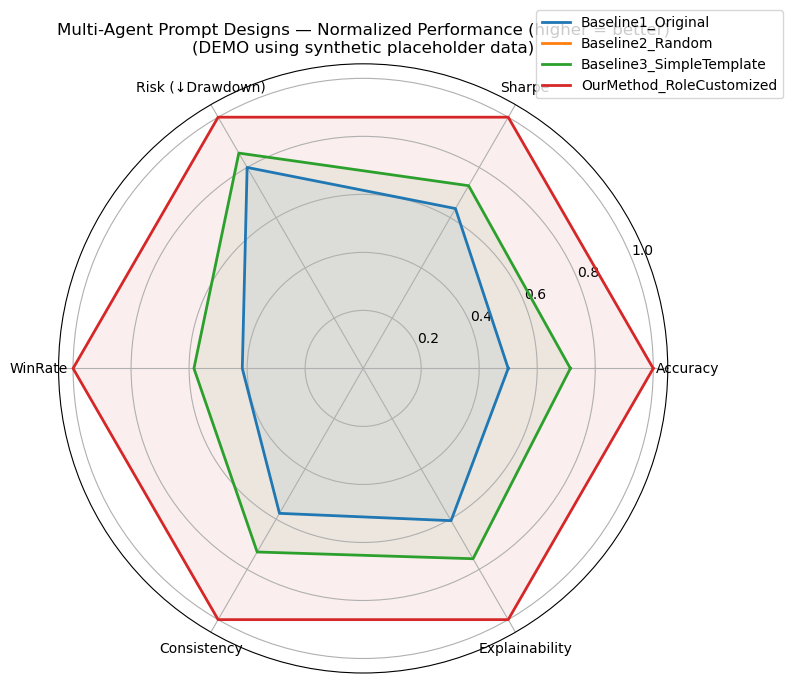

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Generate a radar comparison chart for 4 prompt designs × 6 metrics.
Jupyter Notebook 适配版本
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


METHODS = [
    "Baseline1_Original",
    "Baseline2_Random",
    "Baseline3_SimpleTemplate",
    "OurMethod_RoleCustomized",
]
METRICS = [
    "Accuracy",       # 0-1, higher better
    "Sharpe",         # can be negative, higher better
    "MaxDrawdown",    # 0-1 fraction, LOWER better (we'll invert after normalization)
    "WinRate",        # 0-1, higher better
    "Consistency",    # 0-1, higher better
    "Explainability", # 0-1, higher better
]


def minmax(series: pd.Series) -> pd.Series:
    """Min-Max normalization"""
    smin, smax = series.min(), series.max()
    if smax - smin == 0:
        return pd.Series(np.ones_like(series, dtype=float), index=series.index)
    return (series - smin) / (smax - smin)


def build_radar(df: pd.DataFrame, out_path: str, title: str):
    """构建雷达图"""
    # Normalize
    norm = df.copy()
    for m in METRICS:
        if m != "MaxDrawdown":
            norm[m] = minmax(df[m])
        else:
            norm[m] = 1 - minmax(df[m])  # invert so higher is better

    # Labels for ticks
    labels = [
        "Accuracy",
        "Sharpe",
        "Risk (↓Drawdown)",
        "WinRate",
        "Consistency",
        "Explainability",
    ]

    # Radar angles
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    # Plot
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for method in df["Method"].tolist():
        values = norm.loc[norm["Method"] == method, METRICS].values.flatten()
        values = np.concatenate([values, [values[0]]])
        ax.plot(angles, values, linewidth=2, label=method)
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
    ax.set_title(title, va="bottom")
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"[OK] Saved figure to: {out_path}")
    plt.show()  # 在Jupyter中显示图形


def generate_radar_chart(csv_path=None, out_path="experiment_comparison_radar.png"):
    """
    主函数 - Jupyter 友好版本
    
    参数:
        csv_path: CSV文件路径，如果为None或文件不存在，会生成示例数据
        out_path: 输出图片路径
    """
    # Load or create synthetic
    is_synth = False
    if csv_path and os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        needed = ["Method"] + METRICS
        missing = [c for c in needed if c not in df.columns]
        if missing:
            raise ValueError(f"CSV缺少必要列: {missing}\n需要列为: {needed}")

        # Standardize method order if possible
        try:
            df = df.set_index("Method").reindex(METHODS).reset_index()
            if df["Method"].isna().any():
                df = pd.read_csv(csv_path)
        except Exception:
            df = pd.read_csv(csv_path)

    else:
        print("[WARN] CSV 未找到，将生成占位示例数据。")
        data = {
            "Method": METHODS,
            "Accuracy":       [0.55, 0.48, 0.58, 0.62],
            "Sharpe":         [0.90, 0.20, 1.00, 1.30],
            "MaxDrawdown":    [0.22, 0.50, 0.20, 0.15],  # lower is better
            "WinRate":        [0.52, 0.47, 0.54, 0.59],
            "Consistency":    [0.60, 0.30, 0.68, 0.82],
            "Explainability": [0.60, 0.20, 0.70, 0.86],
        }
        df = pd.DataFrame(data)
        
        # 保存模板CSV
        template_path = "experiment_results_template.csv"
        df.to_csv(template_path, index=False)
        
        is_synth = True

    title = "Multi-Agent Prompt Designs — Normalized Performance (higher = better)"
    if is_synth:
        title += "\n(DEMO using synthetic placeholder data)"

    build_radar(df, out_path, title)
    return df


# ============ Jupyter 中的使用方法 ============

# 方法1: 使用示例数据（自动生成）
df = generate_radar_chart()

# 方法2: 使用你自己的CSV文件
# df = generate_radar_chart(csv_path="your_data.csv", out_path="my_radar.png")

# 方法3: 直接传入DataFrame
# df = pd.DataFrame({...你的数据...})
# build_radar(df, "output.png", "My Title")